# Image Compression Using Singular Value Distribution (SVD)
---
Singular value decomposition is an algorithm used to approximate and compress data in large matrices.



In [19]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt
import numpy as np

# define the image that is being processed
img = 'flowers.jpeg'
img_data = cv2.imread(img)

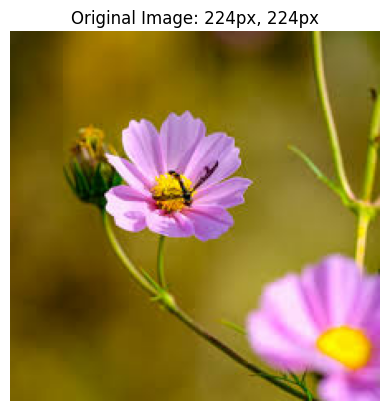

Number of color channels: 3


In [29]:
%matplotlib inline
# Return the current image
def show_image(image, title:str):
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

res = img_data.shape

show_image(img_data, f"Original Image: {res[0]}px, {res[1]}px")
print(f"Number of color channels: {res[2]}")

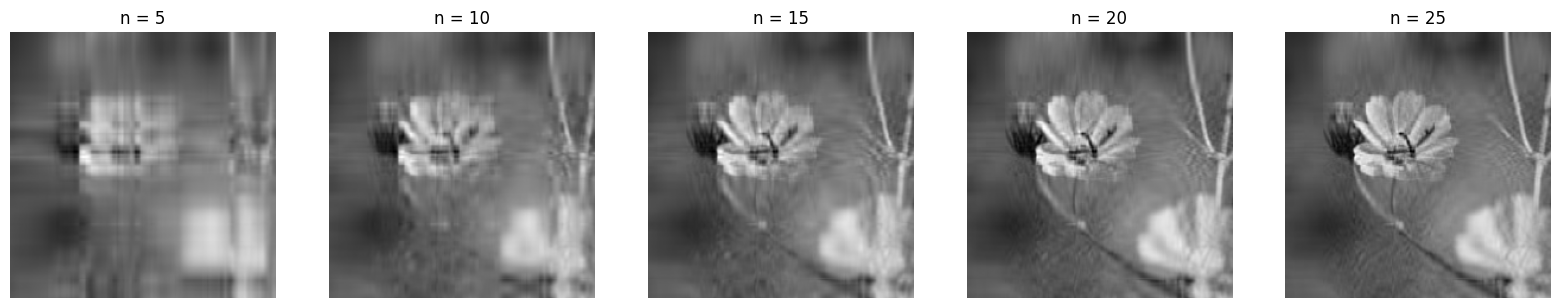

In [ ]:
# for grayscale images / output
def svd_gs(image, sv):
    img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    gs_img = np.matrix(U[:,:sv]) * np.diag(S[:sv]) * np.matrix(Vt[:sv,:])
    return gs_img

# showing the effect on 
plt.figure(figsize=(24,4))
start, end, step = 5, 30, 5
for i in range(start, end, step):
    plt.subplot(1, (end - start) // step + 1, (i - start) // step + 1)
    img_gs = svd_gs(img, i) # does the svd compression
    plt.imshow(img_gs, cmap='grey')
    plt.title('n = %s' % i)
    plt.axis('off')

plt.show()

[]

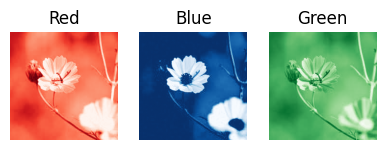

In [ ]:
# splitting color channels
B, G, R = cv2.split(img_data)

plt.subplot(1, 4, 1)
plt.title('Red')
plt.imshow(R, cmap='Reds_r')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(B, cmap='Blues_r')
plt.title('Blue')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(G, cmap='Greens_r')
plt.title('Green')
plt.axis('off')
plt.plot()


In [52]:
# Getting the singular values of the matrix S
# back to the grayscale example


sing_val_ex = cv2.imread(img, cv2.IMREAD_GRAYSCALE)
U, S, Vt = np.linalg.svd(sing_val_ex, full_matrices=False)


# # find the diagonals of matrix S, which is equal to the singular values
# def get_diagonals(matrix):
#     diagonals = []
#     for i in range(len(matrix)):
#         for j in range(len(matrix[0])):
#             if i == j:
#                 diagonals.append(matrix[i][j])
#     return diagonals

np.set_printoptions(precision=2)  # 3 decimal places
print("Singular values of the image")
print(S)

Singular values of the image
[2.66e+04 5.17e+03 2.92e+03 1.94e+03 1.64e+03 1.60e+03 1.13e+03 1.07e+03
 1.01e+03 9.80e+02 8.66e+02 8.56e+02 7.44e+02 7.24e+02 7.04e+02 6.29e+02
 6.06e+02 5.95e+02 5.30e+02 5.19e+02 5.03e+02 4.69e+02 4.47e+02 4.42e+02
 4.24e+02 4.04e+02 3.90e+02 3.70e+02 3.59e+02 3.55e+02 3.34e+02 3.32e+02
 3.16e+02 3.13e+02 3.01e+02 2.90e+02 2.86e+02 2.81e+02 2.68e+02 2.63e+02
 2.54e+02 2.44e+02 2.39e+02 2.30e+02 2.22e+02 2.17e+02 1.99e+02 1.96e+02
 1.91e+02 1.88e+02 1.83e+02 1.80e+02 1.74e+02 1.69e+02 1.63e+02 1.61e+02
 1.53e+02 1.48e+02 1.42e+02 1.40e+02 1.39e+02 1.34e+02 1.30e+02 1.29e+02
 1.23e+02 1.16e+02 1.14e+02 1.11e+02 1.08e+02 1.03e+02 1.01e+02 9.75e+01
 9.61e+01 9.19e+01 9.09e+01 8.58e+01 8.40e+01 8.27e+01 8.09e+01 7.47e+01
 7.38e+01 7.19e+01 7.09e+01 6.85e+01 6.66e+01 6.51e+01 6.18e+01 6.05e+01
 5.81e+01 5.65e+01 5.45e+01 5.30e+01 5.15e+01 5.12e+01 4.87e+01 4.73e+01
 4.63e+01 4.42e+01 4.37e+01 4.30e+01 4.16e+01 3.94e+01 3.83e+01 3.69e+01
 3.50e+01 3.40e+01 3.3

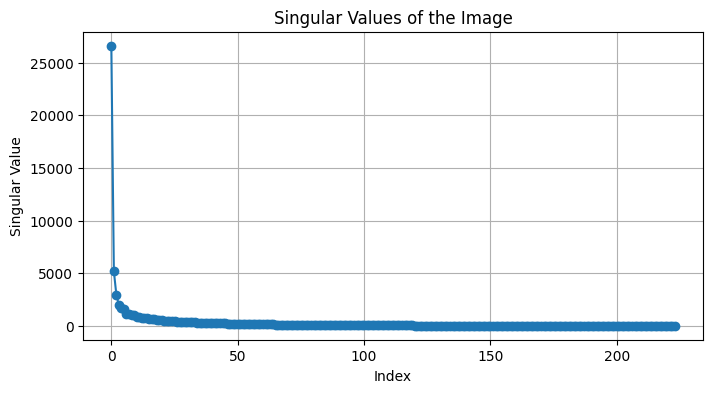

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(S, marker='o')
plt.title("Singular Values of the Image")
plt.xlabel("Index")
plt.ylabel("Singular Value")
plt.grid(True)

plt.subplot(S, marker='o')
plt.title("")
plt.show()